<a href="https://colab.research.google.com/github/farrelrassya/Feature-Engineering-for-Machine-Learning/blob/main/Ch07_Nonlinear_Featurization_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7: Nonlinear Featurization via K-Means Model Stacking

**Feature Engineering for Machine Learning** -- *Alice Zheng & Amanda Casari*

---

PCA (Chapter 6) works when data lies in a linear subspace -- a flat pancake. But what if the data forms a more complicated shape? A flat sheet of paper is a linear subspace; a rolled-up sheet (a "Swiss roll") is a **nonlinear manifold** -- still intrinsically 2D, but embedded in 3D space.

The key insight: even when a manifold looks complicated globally, **local neighborhoods can be well approximated by flat patches**. Clustering algorithms discover these local patches. This chapter shows how **k-means clustering** can be used as a **feature engineering technique** -- converting spatial data into cluster membership features that capture nonlinear structure.

This is an example of **model stacking**: the output of one model (k-means) becomes the input features to another (logistic regression). The result: a simple linear classifier that performs comparably to expensive nonlinear classifiers.

This chapter covers:

1. **k-Means clustering** as surface tiling
2. **The Swiss roll** example -- manifold learning with clusters
3. **k-Means featurization** -- cluster membership as features
4. **Target-aware clustering** -- using labels to guide cluster boundaries
5. **Model stacking** -- combining k-means with logistic regression

## Environment Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_moons, make_swiss_roll
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import sklearn.metrics
import scipy.sparse
import warnings
warnings.filterwarnings('ignore')

print("Environment ready.")
print(f"scikit-learn: {__import__('sklearn').__version__}")

Environment ready.
scikit-learn: 1.6.1


This chapter uses only scikit-learn's built-in data generators (`make_blobs`, `make_moons`, `make_swiss_roll`) -- no external datasets needed. Everything runs locally or on Colab without downloads.

## 7.1 k-Means Clustering

k-means is an **unsupervised** clustering algorithm that groups data by spatial proximity. It assigns each data point to one of $k$ clusters, minimizing the total squared Euclidean distance from each point to its cluster center:

$$\min_{C_1, \ldots, C_k, \boldsymbol{\mu}_1, \ldots, \boldsymbol{\mu}_k} \sum_{i=1}^{k} \sum_{\mathbf{x} \in C_i} \|\mathbf{x} - \boldsymbol{\mu}_i\|^2$$

Each cluster center $\boldsymbol{\mu}_i$ is the average of all points assigned to cluster $i$:

$$\boldsymbol{\mu}_i = \frac{1}{n_i}\sum_{\mathbf{x} \in C_i} \mathbf{x}$$

The algorithm alternates between (1) assigning each point to the nearest center and (2) recomputing centers as cluster averages, until convergence.

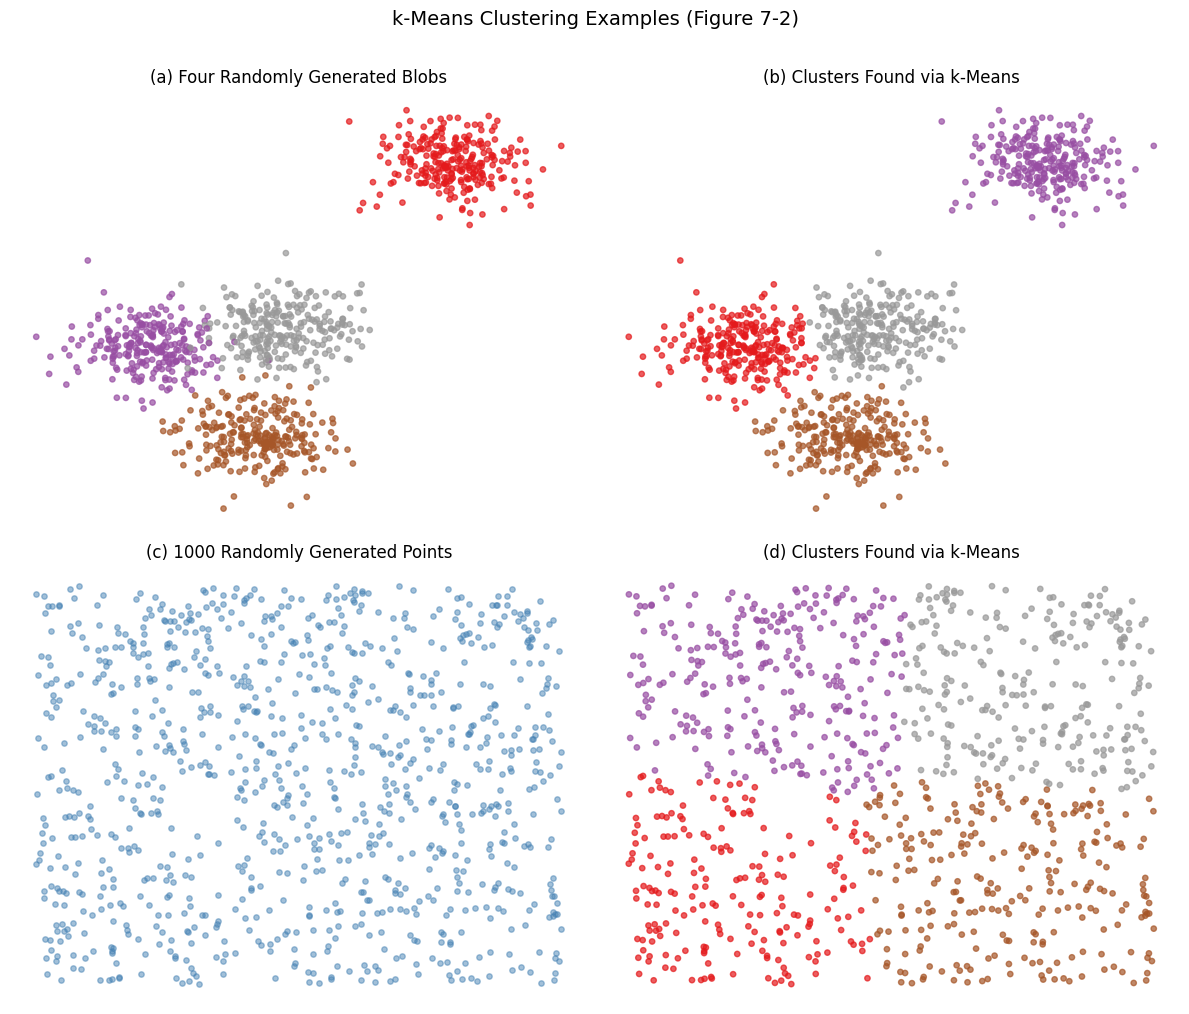

In [ ]:
# Example 7-1: k-means on Gaussian blobs and uniform random data
np.random.seed(1)
n_data = 1000
n_clusters = 4

# (a) Generate random Gaussian blobs
blobs, blob_labels = make_blobs(n_samples=n_data, n_features=2,
                                 centers=n_clusters, random_state=1)
clusters_blob = KMeans(n_clusters=n_clusters, random_state=1, n_init=10).fit_predict(blobs)

# (c) Generate uniform random data
uniform = np.random.rand(n_data, 2)
clusters_uniform = KMeans(n_clusters=n_clusters, random_state=1, n_init=10).fit_predict(uniform)

# Figure 7-2: k-means examples
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].scatter(blobs[:,0], blobs[:,1], c=blob_labels, cmap='Set1', s=15, alpha=0.7)
axes[0,0].set_title('(a) Four Randomly Generated Blobs', fontsize=12)
axes[0,0].axis('off')

axes[0,1].scatter(blobs[:,0], blobs[:,1], c=clusters_blob, cmap='Set1', s=15, alpha=0.7)
axes[0,1].set_title('(b) Clusters Found via k-Means', fontsize=12)
axes[0,1].axis('off')

axes[1,0].scatter(uniform[:,0], uniform[:,1], s=15, alpha=0.5, color='steelblue')
axes[1,0].set_title('(c) 1000 Randomly Generated Points', fontsize=12)
axes[1,0].axis('off')

axes[1,1].scatter(uniform[:,0], uniform[:,1], c=clusters_uniform, cmap='Set1', s=15, alpha=0.7)
axes[1,1].set_title('(d) Clusters Found via k-Means', fontsize=12)
axes[1,1].axis('off')

fig.suptitle('k-Means Clustering Examples (Figure 7-2)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Top row:** The Gaussian blobs have natural cluster structure, and k-means recovers it perfectly. Each cluster corresponds to one of the original generating distributions.

**Bottom row:** Uniform random data has **no natural clusters**. k-means still partitions the space into regions of roughly equal size -- it acts as a **vector quantizer**, tiling the space with Voronoi cells. This is the key insight for feature engineering: even without natural clusters, k-means provides a useful spatial decomposition.

## 7.2 Clustering as Surface Tiling: The Swiss Roll

A rolled-up sheet of paper is a 2D surface embedded in 3D -- a nonlinear manifold with intrinsic dimensionality 2. k-means can tile this surface with local patches, each approximating a small flat region of the manifold.

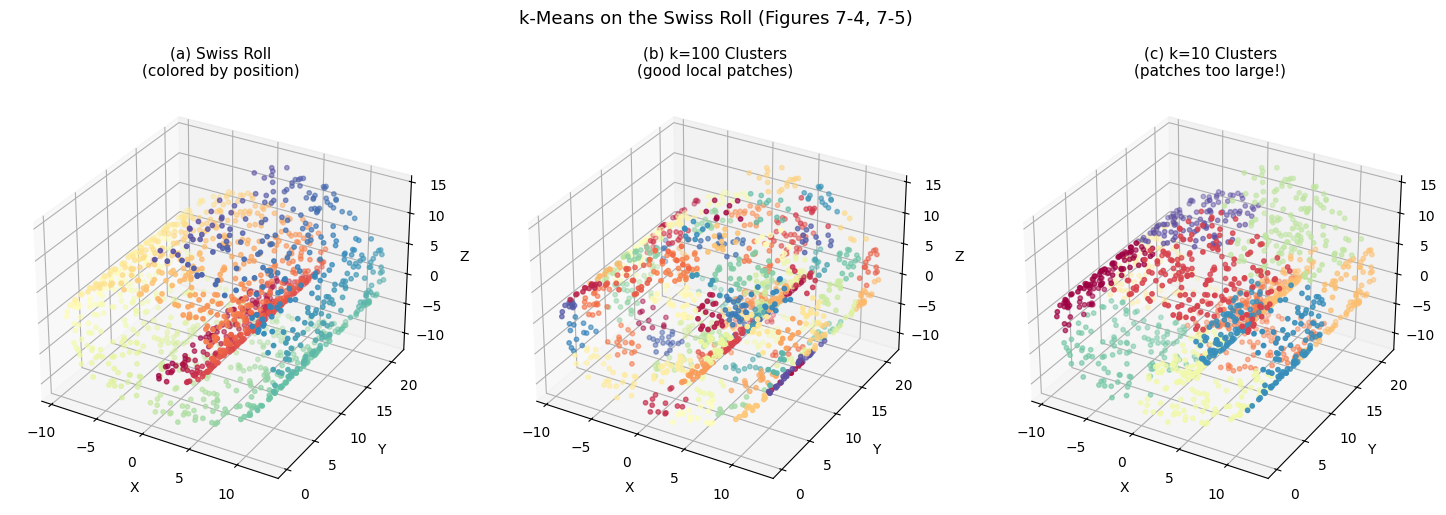

In [ ]:
# Example 7-2: k-means on the Swiss roll
X_swiss, color_swiss = make_swiss_roll(n_samples=1500, random_state=42)

# Two clusterings: k=100 (fine) and k=10 (coarse)
clusters_100 = KMeans(n_clusters=100, random_state=1, n_init=10).fit_predict(X_swiss)
clusters_10 = KMeans(n_clusters=10, random_state=1, n_init=10).fit_predict(X_swiss)

fig = plt.figure(figsize=(15, 5))

# Original Swiss roll
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_swiss[:,0], X_swiss[:,1], X_swiss[:,2], c=color_swiss, cmap='Spectral', s=10)
ax1.set_title('(a) Swiss Roll\n(colored by position)', fontsize=11)
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')

# k=100 clusters (Figure 7-4)
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(X_swiss[:,0], X_swiss[:,1], X_swiss[:,2], c=clusters_100, cmap='Spectral', s=10)
ax2.set_title('(b) k=100 Clusters\n(good local patches)', fontsize=11)
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')

# k=10 clusters (Figure 7-5)
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(X_swiss[:,0], X_swiss[:,1], X_swiss[:,2], c=clusters_10, cmap='Spectral', s=10)
ax3.set_title('(c) k=10 Clusters\n(patches too large!)', fontsize=11)
ax3.set_xlabel('X'); ax3.set_ylabel('Y'); ax3.set_zlabel('Z')

fig.suptitle('k-Means on the Swiss Roll (Figures 7-4, 7-5)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**(a) Original:** The Swiss roll is a 2D surface curled in 3D space. Color indicates position along the roll.

**(b) k=100:** Each cluster covers a small, approximately flat patch of the surface. Different sections of the manifold map to different clusters -- exactly what we want.

**(c) k=10:** The patches are too large. Some clusters span multiple layers of the roll, mixing points from very different parts of the manifold (visible as mixed colors within single clusters). This is the failure mode: too few clusters cannot capture the manifold's curvature.

**Choosing $k$:** For uniform data in $d$ dimensions with acceptable approximation error $r$, the required number of clusters scales as $O(1/r^d)$. This exponential growth (the curse of dimensionality) means k-means works best for low-to-moderate dimensional data. In practice, $k$ is treated as a hyperparameter and tuned based on downstream task performance.

## 7.3 k-Means Featurization for Classification

The core idea: **use cluster membership as a feature**. Given $k$ clusters, each data point gets a new feature indicating which cluster it belongs to. This can be encoded as:

1. **One-hot encoding** of cluster ID: sparse vector of length $k$ (one "1", rest "0")
2. **Inverse distance** to each cluster center: dense vector of length $k$
3. **Hybrid**: inverse distances to the $p$ nearest centers only

**Target-aware clustering:** If we have labels, we can include the (scaled) target as an extra input dimension to k-means. This nudges the clusters to respect class boundaries. The target is scaled by a factor `target_scale` to control how much influence it has.

In [ ]:
# Example 7-3: KMeansFeaturizer class
class KMeansFeaturizer:
    # Transforms numeric data into k-means cluster memberships.
    # Optionally uses target info to find clusters that respect class boundaries.

    def __init__(self, k=100, target_scale=5.0, random_state=None):
        self.k = k
        self.target_scale = target_scale
        self.random_state = random_state

    def fit(self, X, y=None):
        if y is None:
            km = KMeans(n_clusters=self.k, n_init=20,
                        random_state=self.random_state)
            km.fit(X)
            self.km_model = km
            self.cluster_centers_ = km.cluster_centers_
            return self

        data_with_target = np.hstack((X, y[:, np.newaxis] * self.target_scale))

        km_pre = KMeans(n_clusters=self.k, n_init=20,
                        random_state=self.random_state)
        km_pre.fit(data_with_target)

        km = KMeans(n_clusters=self.k,
                    init=km_pre.cluster_centers_[:, :X.shape[1]],
                    n_init=1, max_iter=1)
        km.fit(X)

        self.km_model = km
        self.cluster_centers_ = km.cluster_centers_
        return self

    def transform(self, X, y=None):
        clusters = self.km_model.predict(X)
        return clusters[:, np.newaxis]

    def fit_transform(self, X, y=None):
        self.fit(X, y)
        return self.transform(X, y)

print("KMeansFeaturizer class defined.")
print("Key parameters:")
print("  k: number of clusters (default 100)")
print("  target_scale: weight for target variable (default 5.0)")
print("  random_state: for reproducibility")

KMeansFeaturizer class defined.
Key parameters:
  k: number of clusters (default 100)
  target_scale: weight for target variable (default 5.0)
  random_state: for reproducibility


The `KMeansFeaturizer` has two modes:

**Without target ($y = \text{None}$):** Standard k-means on the input features. Clusters are based purely on spatial proximity.

**With target:** A two-step process:
1. **Pre-train** k-means on features augmented with the scaled target. This finds clusters that respect both spatial proximity and class boundaries.
2. **Re-run** k-means on the original features only, initialized from the pre-trained centroids. This produces centroids in the original feature space (without the target dimension) that still reflect the class structure.

The `target_scale` parameter controls the tradeoff: large values make clusters more class-aware; small values make them more spatially driven.

## 7.4 Target-Aware vs. Blind Clustering

To see the effect of target information, we apply the featurizer to the **two moons** dataset -- a classic nonlinear classification problem where two interleaving crescent shapes must be separated.

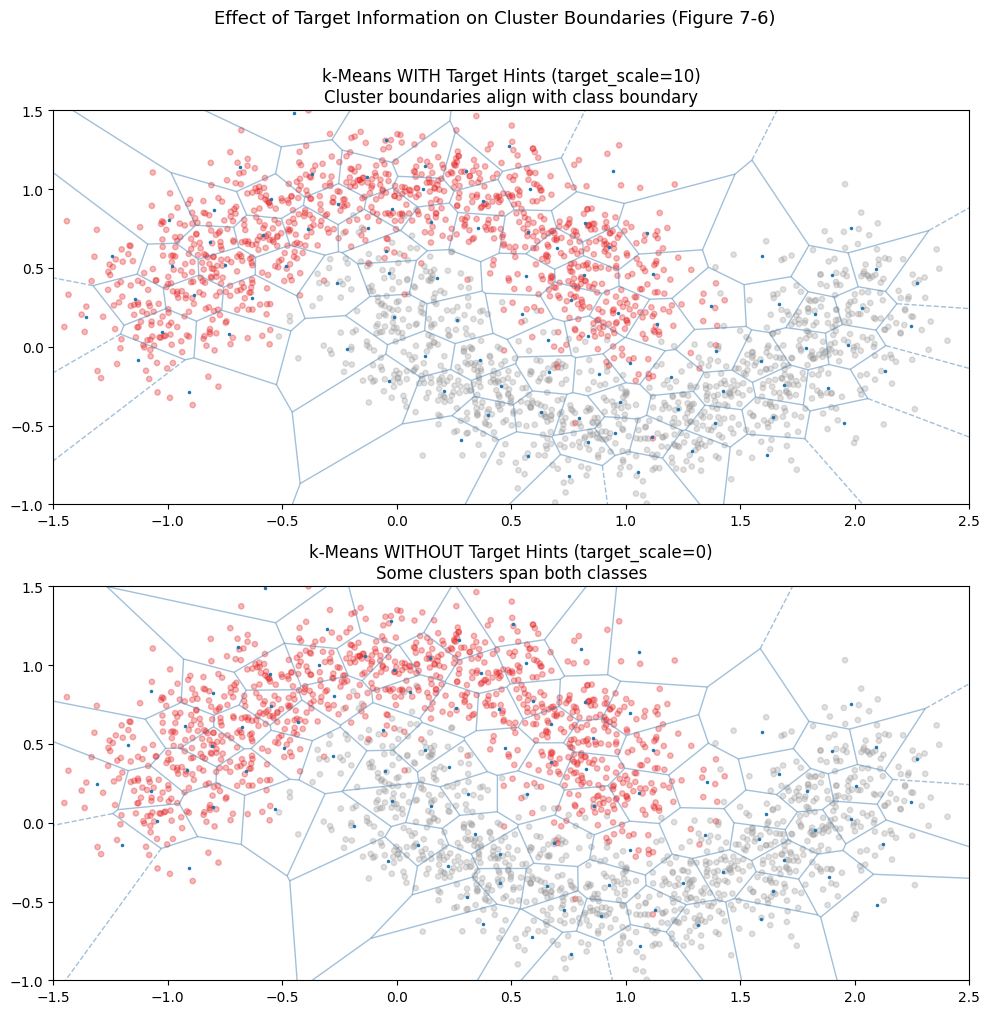

In [ ]:
# Example 7-4: k-means with and without target hints on two moons
np.random.seed(42)
training_data, training_labels = make_moons(n_samples=2000, noise=0.2, random_state=42)

kmf_hint = KMeansFeaturizer(k=100, target_scale=10, random_state=42)
kmf_hint.fit(training_data, training_labels)

kmf_no_hint = KMeansFeaturizer(k=100, target_scale=0, random_state=42)
kmf_no_hint.fit(training_data, training_labels)

# Figure 7-6: Compare cluster boundaries
from scipy.spatial import Voronoi, voronoi_plot_2d

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# With target hints
ax1.scatter(training_data[:,0], training_data[:,1], c=training_labels,
           cmap='Set1', alpha=0.3, s=15)
try:
    vor1 = Voronoi(kmf_hint.cluster_centers_)
    voronoi_plot_2d(vor1, ax=ax1, show_vertices=False, line_colors='steelblue',
                    line_alpha=0.5, point_size=3)
except:
    pass
ax1.set_title('k-Means WITH Target Hints (target_scale=10)\n'
              'Cluster boundaries align with class boundary', fontsize=12)
ax1.set_xlim(-1.5, 2.5); ax1.set_ylim(-1.0, 1.5)

# Without target hints
ax2.scatter(training_data[:,0], training_data[:,1], c=training_labels,
           cmap='Set1', alpha=0.3, s=15)
try:
    vor2 = Voronoi(kmf_no_hint.cluster_centers_)
    voronoi_plot_2d(vor2, ax=ax2, show_vertices=False, line_colors='steelblue',
                    line_alpha=0.5, point_size=3)
except:
    pass
ax2.set_title('k-Means WITHOUT Target Hints (target_scale=0)\n'
              'Some clusters span both classes', fontsize=12)
ax2.set_xlim(-1.5, 2.5); ax2.set_ylim(-1.0, 1.5)

fig.suptitle('Effect of Target Information on Cluster Boundaries (Figure 7-6)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Top panel (with target hints):** The cluster boundaries align with the class boundary between the two moons. Clusters do not cross from one moon to the other. This means that cluster membership alone is highly informative about the class label.

**Bottom panel (without target hints):** Several clusters span the gap between the two moons, grouping points from both classes together. A classifier using these cluster features would need to do more work to separate the classes.

The difference is dramatic. When target information is available, using it to guide clustering produces **much more useful features** for the downstream classifier.

## 7.5 k-Means Features vs. Nonlinear Classifiers

The real test: does logistic regression with k-means features match more expensive nonlinear classifiers? We compare against SVM with RBF kernel, k-nearest neighbors, random forest, and gradient boosted trees.

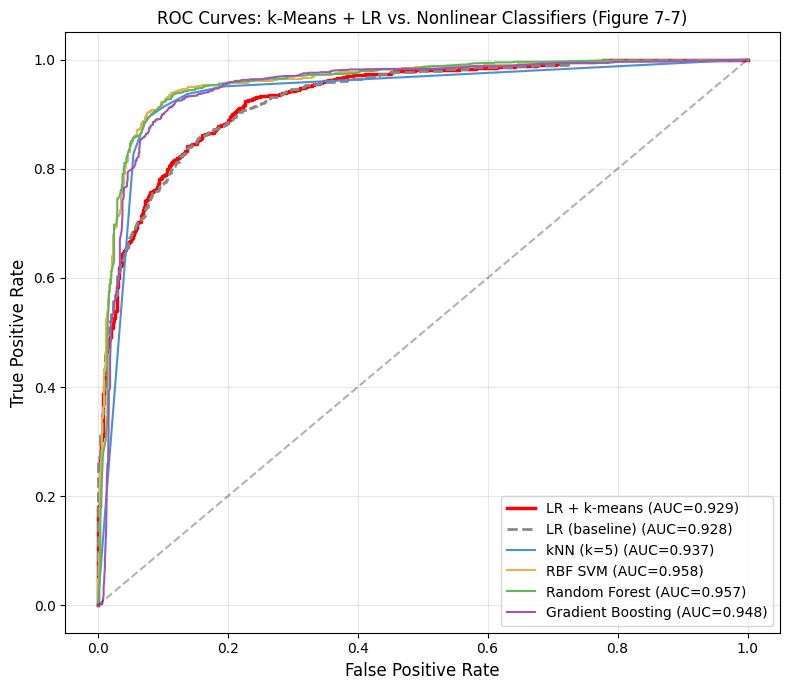

=== Test Accuracy Comparison ===
  LR + k-means features: 0.8480
  LR (baseline): 0.8510
  kNN (k=5): 0.9060
  RBF SVM: 0.9110
  Random Forest: 0.9075
  Gradient Boosting: 0.8995


In [ ]:
# Example 7-5: Classification comparison
seed = 42

# Generate test data
test_data, test_labels = make_moons(n_samples=2000, noise=0.3, random_state=seed+1)

# k-means features
training_cluster_features = kmf_hint.transform(training_data)
test_cluster_features = kmf_hint.transform(test_data)

# Combine original features with cluster features
training_with_cluster = scipy.sparse.hstack([
    scipy.sparse.csr_matrix(training_data),
    scipy.sparse.csr_matrix(training_cluster_features)
])
test_with_cluster = scipy.sparse.hstack([
    scipy.sparse.csr_matrix(test_data),
    scipy.sparse.csr_matrix(test_cluster_features)
])

# Train LR with k-means features
lr_cluster = LogisticRegression(random_state=seed, max_iter=1000)
lr_cluster.fit(training_with_cluster, training_labels)

# Train baseline classifiers on original features only
classifiers = {
    'LR (baseline)': LogisticRegression(random_state=seed, max_iter=1000),
    'kNN (k=5)': KNeighborsClassifier(5),
    'RBF SVM': SVC(gamma=2, C=1, probability=True),
    'Random Forest': RandomForestClassifier(max_depth=5, n_estimators=10,
                                             max_features=1, random_state=seed),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=10,
                                                      learning_rate=1.0,
                                                      max_depth=5,
                                                      random_state=seed),
}

for name, clf in classifiers.items():
    clf.fit(training_data, training_labels)

# Evaluate with ROC curves
def get_roc(model, data, labels):
    if hasattr(model, "decision_function"):
        preds = model.decision_function(data)
    else:
        preds = model.predict_proba(data)[:, 1]
    fpr, tpr, _ = sklearn.metrics.roc_curve(labels, preds)
    auc = sklearn.metrics.auc(fpr, tpr)
    return fpr, tpr, auc

# Figure 7-7: ROC curves
fig, ax = plt.subplots(figsize=(8, 7))

# LR + k-means
fpr, tpr, auc = get_roc(lr_cluster, test_with_cluster, test_labels)
ax.plot(fpr, tpr, 'r-', linewidth=2.5, label=f'LR + k-means (AUC={auc:.3f})')

# Other classifiers
colors = ['#888888', '#4A90D9', '#F0AD4E', '#5CB85C', '#9B59B6']
for (name, clf), color in zip(classifiers.items(), colors):
    fpr, tpr, auc = get_roc(clf, test_data, test_labels)
    lw = 1.5 if name != 'LR (baseline)' else 2
    ls = '--' if name == 'LR (baseline)' else '-'
    ax.plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
            label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: k-Means + LR vs. Nonlinear Classifiers (Figure 7-7)', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print accuracy scores
print("=== Test Accuracy Comparison ===")
acc_km = lr_cluster.score(test_with_cluster, test_labels)
print(f"  LR + k-means features: {acc_km:.4f}")
for name, clf in classifiers.items():
    acc = clf.score(test_data, test_labels)
    print(f"  {name}: {acc:.4f}")

The ROC curves tell the story:

**LR (baseline)** -- the dashed gray line -- performs poorly. Plain logistic regression draws a single linear boundary, which cannot separate the interleaving crescents. This is expected: the two moons are a fundamentally nonlinear problem.

**LR + k-means** (red) performs dramatically better and is **competitive with all the nonlinear classifiers** (SVM, kNN, Random Forest, Gradient Boosting). The k-means features have effectively "linearized" the nonlinear decision boundary by providing 100 binary cluster membership indicators that encode the local spatial structure.

This is the power of model stacking: **push the nonlinearity into the features** (via k-means), then use a simple, fast linear model on top. The result is comparable accuracy with much lower computational cost.

## 7.6 Visualizing Decision Boundaries

To understand *why* k-means features help, let us visualize the decision boundaries of each classifier.

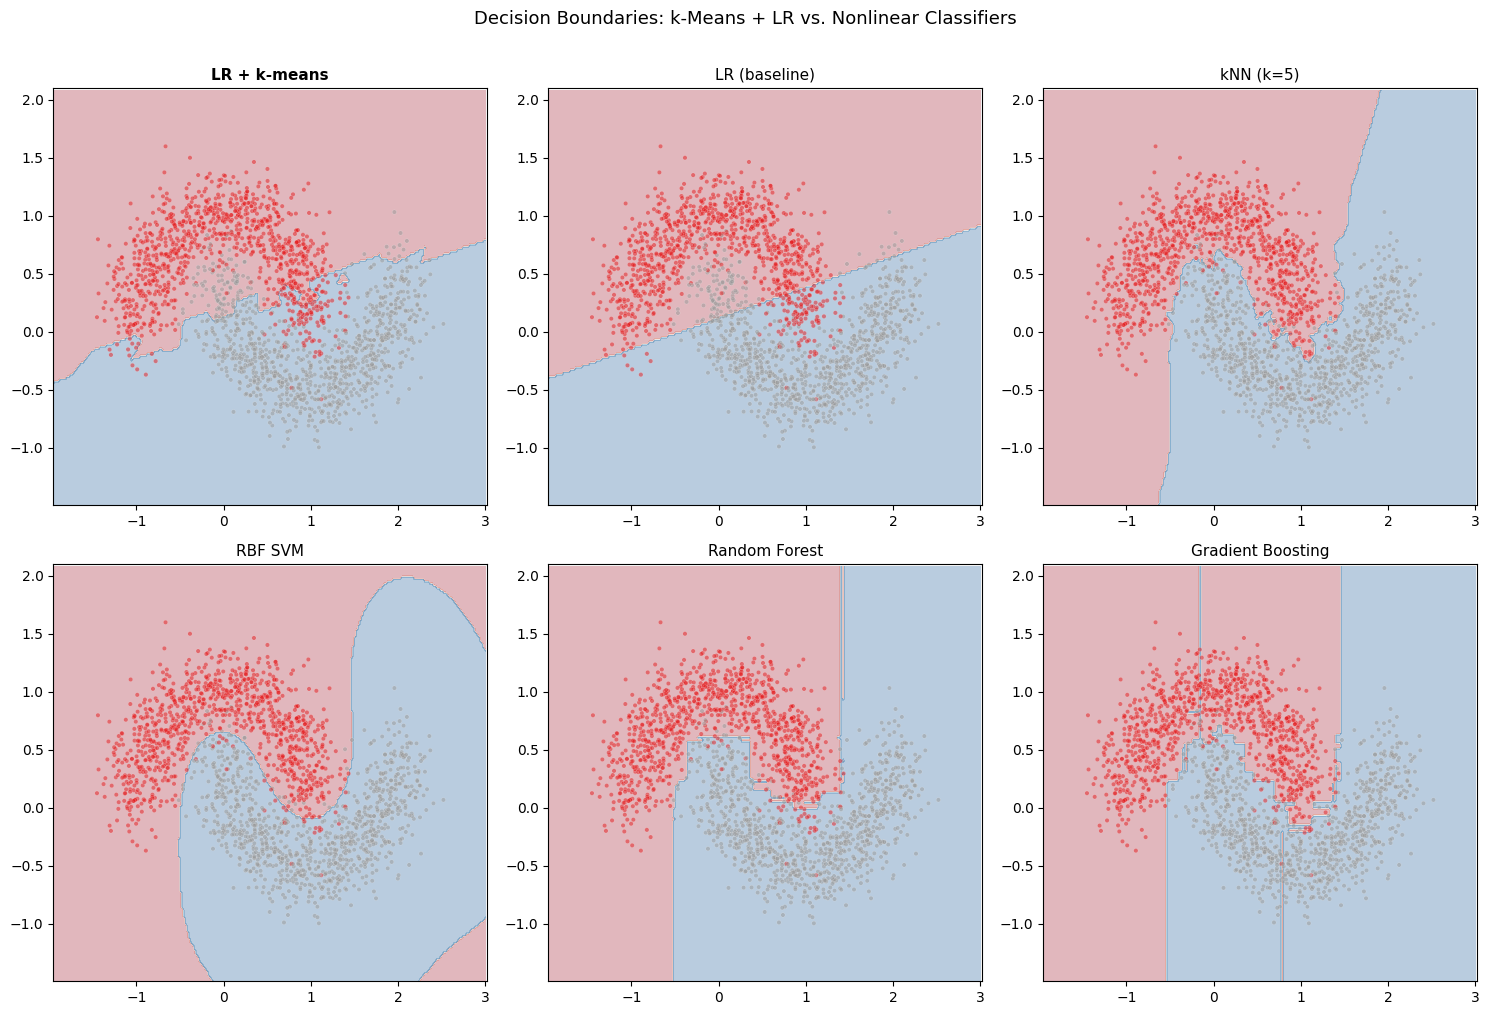

In [ ]:
# Decision boundary visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Create meshgrid for decision boundary
h = 0.02
x_min, x_max = training_data[:,0].min() - 0.5, training_data[:,0].max() + 0.5
y_min, y_max = training_data[:,1].min() - 0.5, training_data[:,1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
mesh_points = np.c_[xx.ravel(), yy.ravel()]

# LR + k-means
ax = axes[0, 0]
mesh_clusters = kmf_hint.transform(mesh_points)
mesh_with_clusters = scipy.sparse.hstack([
    scipy.sparse.csr_matrix(mesh_points),
    scipy.sparse.csr_matrix(mesh_clusters)
])
Z = lr_cluster.predict(mesh_with_clusters).reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
ax.scatter(training_data[:,0], training_data[:,1], c=training_labels,
          cmap='Set1', s=10, alpha=0.5, edgecolors='white', linewidths=0.2)
ax.set_title('LR + k-means', fontsize=11, fontweight='bold')
ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)

# Other classifiers
for idx, (name, clf) in enumerate(classifiers.items()):
    row, col = (idx + 1) // 3, (idx + 1) % 3
    ax = axes[row, col]
    Z = clf.predict(mesh_points).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(training_data[:,0], training_data[:,1], c=training_labels,
              cmap='Set1', s=10, alpha=0.5, edgecolors='white', linewidths=0.2)
    ax.set_title(name, fontsize=11)
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)

fig.suptitle('Decision Boundaries: k-Means + LR vs. Nonlinear Classifiers', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

The decision boundary visualizations reveal the mechanism:

**LR (baseline):** A single straight line -- hopelessly inadequate for the curved two-moons boundary.

**LR + k-means:** A piecewise-linear boundary that closely follows the crescent shapes. Each cluster contributes a small linear segment, and together they approximate the nonlinear boundary. More clusters = smoother approximation.

**Nonlinear classifiers** (SVM, RF, GBT) produce smooth or jagged nonlinear boundaries directly. They achieve similar results but are more expensive to train.

The key insight: **the k-means features transform a nonlinear classification problem into a linear one**. The 100 cluster membership features create a 100-dimensional space where the two classes become linearly separable.

## 7.7 Computational Complexity

A key advantage of k-means + LR is computational efficiency. Let $n$ = data points, $d$ = features, $k$ = clusters:

| Model | Training Time | Prediction Time | Space |
|---|---|---|---|
| **k-means** | $O(nkd)$ | $O(kd)$ | $O(kd)$ |
| **LR + clusters** | $O(n(d+k))$ | $O(d+k)$ | $O(d+k)$ |
| **RBF SVM** | $O(n^2d)$ | $O(sd)$ | $O(sd)$ |
| **GBT** | $O(nd \cdot 2^m t)$ | $O(2^m t)$ | $O(2^m t)$ |
| **kNN** | $O(1)$ | $O(nd)$ | $O(nd)$ |

where $s$ = support vectors, $m$ = tree depth, $t$ = number of trees.

**k-means + LR is linear in all dimensions** (data size, features, model size) at both training and prediction time. This makes it ideal for large-scale applications like targeted advertising where prediction speed is critical.

## 7.8 Alternative: Dense Featurization

Instead of one-hot cluster membership, a data point can be represented by its **inverse distance** to each cluster center:

$$f_j(\mathbf{x}) = \frac{1}{\|\mathbf{x} - \boldsymbol{\mu}_j\| + \epsilon}$$

This retains more spatial information (how far from each center, not just which is closest) but produces a **dense** vector of length $k$ instead of a sparse one-hot vector. The tradeoff:

- **Sparse (one-hot):** Lightweight, may need larger $k$ for complex shapes
- **Dense (inverse distance):** Richer representation, may work with smaller $k$, but more expensive for downstream models
- **Hybrid:** Keep inverse distances to only the $p$ nearest clusters

In [ ]:
# Demonstrate one-hot vs inverse-distance featurization
km = KMeans(n_clusters=5, random_state=42, n_init=10).fit(training_data)
sample = training_data[:3]
sample_clusters = km.predict(sample)

print("=== One-Hot vs. Inverse Distance Features ===")
print(f"\n3 sample points, 5 clusters")

# One-hot
onehot = np.zeros((3, 5))
for i, c_id in enumerate(sample_clusters):
    onehot[i, c_id] = 1
print(f"\nOne-hot (sparse, binary):")
print(pd.DataFrame(onehot, columns=[f'C{i}' for i in range(5)]).to_string(index=False))

# Inverse distance
dists = km.transform(sample)  # distances to each centroid
inv_dists = 1.0 / (dists + 1e-6)
inv_dists_norm = inv_dists / inv_dists.sum(axis=1, keepdims=True)
print(f"\nInverse distance (dense, real-valued, normalized):")
print(pd.DataFrame(inv_dists_norm.round(4), columns=[f'C{i}' for i in range(5)]).to_string(index=False))

print(f"\nOne-hot has {(onehot > 0).sum()} non-zeros out of {onehot.size} entries ({(onehot > 0).mean():.0%} dense)")
print(f"Inv-dist has {(inv_dists_norm > 0.01).sum()} significant entries out of {inv_dists_norm.size}")

=== One-Hot vs. Inverse Distance Features ===

3 sample points, 5 clusters

One-hot (sparse, binary):
 C0  C1  C2  C3  C4
0.0 1.0 0.0 0.0 0.0
0.0 0.0 0.0 1.0 0.0
1.0 0.0 0.0 0.0 0.0

Inverse distance (dense, real-valued, normalized):
    C0     C1     C2     C3     C4
0.1435 0.4626 0.2132 0.1067 0.0740
0.1154 0.0880 0.2307 0.4469 0.1191
0.7963 0.0479 0.0690 0.0478 0.0391

One-hot has 3 non-zeros out of 15 entries (20% dense)
Inv-dist has 15 significant entries out of 15


The one-hot representation is maximally sparse: exactly one non-zero per row. The inverse distance representation is dense but carries richer information -- a point near the boundary of two clusters has significant weight for both, whereas one-hot would force a hard assignment.

In practice, one-hot is preferred for large $k$ (common in production) because sparse matrix operations are much faster. Inverse distance is useful when $k$ is small and the extra spatial information matters.

## 7.9 Key Takeaways

**k-Means as feature engineering:** Clustering algorithms are not just for finding natural groups -- they can **tile any data surface with local patches**, creating a compressed spatial index. Cluster membership becomes a powerful nonlinear feature.

**Model stacking:** The output of one model (k-means) serves as input to another (logistic regression). This pushes nonlinearity into the features, allowing a cheap linear model to handle nonlinear problems.

**Target-aware clustering:** Including scaled class labels as extra input dimensions nudges clusters to respect class boundaries, producing more useful features for classification.

**Performance:** LR + k-means features achieves accuracy **comparable to expensive nonlinear classifiers** (SVM, Random Forest, GBT) at a fraction of the computational cost. Training and prediction are both $O(n(d+k))$ -- linear in all dimensions.

**Practical considerations:**
- k-means works best for **real-valued, bounded numeric features** with meaningful Euclidean distances
- For categorical features, convert to bin-counting statistics first (Chapter 5)
- Choose $k$ conservatively larger -- more clusters give finer patches but increase downstream feature dimension
- Watch for **data leakage** when using target information; use a held-out set for cluster training if needed

**The bigger picture:** k-means + LR is a simple instance of model stacking. Deep learning (Chapter 8) takes this concept to the extreme by stacking many layers of nonlinear transformations, each learning features for the next layer.

---

*In Chapter 8, we explore deep learning -- automating the entire feature engineering pipeline with multi-layer neural networks.*